# Data Cleaning Phases
The followng code is segregated by markdowns each approximately corressponding to a factor we deemed to have a relation to malaria rates. These however,are only data that were accessible via csvs, API requests will come wtih a separate notebook.

In [249]:
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import time
import requests

Data sources:

World Health Organization:
https://www.who.int/data/gho/data/indicators/indicator-details/GHO/number-confirmed-malaria-cases

World Bank group:
https://data.worldbank.org/indicator/NY.GDP.PCAP.CD
https://data.worldbank.org/indicator/SP.URB.TOTL.IN.ZS
https://data.worldbank.org/indicator/SP.URB.TOTL.IN.ZS
https://data.worldbank.org/indicator/SH.STA.BASS.ZS

# Phase 1: Malaria
Datacleaning WHO malaria data

In [182]:
df = pd.read_csv('https://raw.githubusercontent.com/ZacharyMalonjao/Capstone2-A3101-Group2-SY26-27/refs/heads/main/spreadsheets/malaria.csv')
df.head()

,IndicatorCode,Indicator,ValueType,ParentLocationCode,ParentLocation,Location type,SpatialDimValueCode,Location,Period type,Period,...,FactValueUoM,FactValueNumericLowPrefix,FactValueNumericLow,FactValueNumericHighPrefix,FactValueNumericHigh,Value,FactValueTranslationID,FactComments,Language,DateModified
0,MALARIA_CONF_CASES,Number of confirmed malaria cases,numeric,EUR,Europe,Country,TKM,Turkmenistan,Year,2024,...,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,EN,2025-12-18T16:00:00.000Z
1,MALARIA_CONF_CASES,Number of confirmed malaria cases,numeric,EUR,Europe,Country,UZB,Uzbekistan,Year,2024,...,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,EN,2025-12-18T16:00:00.000Z
2,MALARIA_CONF_CASES,Number of confirmed malaria cases,numeric,AMR,Americas,Country,BLZ,Belize,Year,2024,...,NaN,NaN,NaN,NaN,NaN,1,NaN,NaN,EN,2025-12-18T16:00:00.000Z
3,MALARIA_CONF_CASES,Number of confirmed malaria cases,numeric,SEAR,South-East Asia,Country,TLS,Timor-Leste,Year,2024,...,NaN,NaN,NaN,NaN,NaN,1,NaN,NaN,EN,2025-12-18T16:00:00.000Z
4,MALARIA_CONF_CASES,Number of confirmed malaria cases,numeric,AFR,Africa,Country,BEN,Benin,Year,2024,...,NaN,NaN,NaN,NaN,NaN,1 739 412,NaN,NaN,EN,2025-12-18T16:00:00.000Z


In [183]:
#Im going to grab the essential and essentially pivot it lengthwise. You'll see as the code progresses.
df_clean =  df[['Location', 'Period', 'FactValueNumeric', 'ParentLocationCode', 'SpatialDimValueCode']]
df_clean.head()

,Location,Period,FactValueNumeric,ParentLocationCode,SpatialDimValueCode
0,Turkmenistan,2024,0,EUR,TKM
1,Uzbekistan,2024,0,EUR,UZB
2,Belize,2024,1,AMR,BLZ
3,Timor-Leste,2024,1,SEAR,TLS
4,Benin,2024,1739412,AFR,BEN


In [184]:
#check for duplicates
print(df.groupby(['Location', 'Period']).size().max()) 
#double check

1


In [185]:
#Here's where the pivoting starts
df_wide = df_clean.pivot_table(
    index = 'Location',
    columns = 'Period',
    values='FactValueNumeric',
    aggfunc='sum'
).reset_index()

df_wide.columns = ['Country'] + [f'cases_{yr}' for yr in df_wide.columns[1:]]

#merge back the other metadata
meta = df_clean[['Location', 'ParentLocationCode', 'SpatialDimValueCode']].drop_duplicates()
df_wide = df_wide.merge(meta, left_on='Country', right_on='Location').drop(columns='Location')
#just reorder
df_wide = df_wide[['Country', 'ParentLocationCode', 'SpatialDimValueCode'] + [c for c in df_wide.columns if c.startswith('cases_')]]

print(df_wide.head())
#df_wide.to_csv('malaria_wide.csv', index=False)
#If we're going for a time series study, this datat is cool, but we're doing regression so onward me must press on

       Country ParentLocationCode SpatialDimValueCode  cases_2015  cases_2016  \
0  Afghanistan                EMR                 AFG    119859.0    241233.0   
1      Algeria                AFR                 DZA       747.0       432.0   
2       Angola                AFR                 AGO   2769305.0   3794253.0   
3    Argentina                AMR                 ARG        11.0         9.0   
4      Armenia                EUR                 ARM         2.0         2.0   

   cases_2017  cases_2018  cases_2019  cases_2020  cases_2021  cases_2022  \
0    313086.0    248689.0    173860.0    105295.0     86263.0    125620.0   
1       453.0      1242.0      1014.0      2726.0      1164.0      1292.0   
2   3874892.0   5150575.0   7054978.0   7343696.0   8325921.0   7858860.0   
3        16.0        28.0        22.0        13.0        13.0        10.0   
4         2.0         6.0         NaN         3.0         NaN         2.0   

   cases_2023  cases_2024  
0    180045.0    25752

In [186]:
#check for empty metadata
print(df_clean['ParentLocationCode'].isna().sum())
print(df_clean['SpatialDimValueCode'].isna().sum())

0
0


In [187]:
#Sir Edmon said we need to check for normality before we aggregate.
# If atleast one country is not normal, we aggregate the cases by median
#We're using Shapio-Wilk Test for this

year_cols = [c for c in df_wide.columns if c.startswith('cases_')]


results = []
for _, row in df_wide.iterrows():
    values = row[year_cols].dropna().values
    
    # Need at least 3 data points to test
    if len(values) < 3:
        results.append({'Country': row['Country'], 'p_value': None, 'normal': None})
        continue
    
    stat, p = stats.shapiro(values)
    results.append({
        'Country': row['Country'],
        'p_value': round(p, 4),
        'normal': p > 0.05  # True = normal, False = skewed
    })

normality_df = pd.DataFrame(results)
print(normality_df)

#Those are a substantial amount of skewed data, so we're using median for aggregation

                                Country  p_value  normal
0                           Afghanistan   0.4867    True
1                               Algeria   0.0210   False
2                                Angola   0.7020    True
3                             Argentina   0.1664    True
4                               Armenia   0.0021   False
..                                  ...      ...     ...
98   Venezuela (Bolivarian Republic of)   0.0303   False
99                             Viet Nam   0.0375   False
100                               Yemen   0.4698    True
101                              Zambia   0.2106    True
102                            Zimbabwe   0.5008    True

[103 rows x 3 columns]


In [188]:
df_wide['Median_Malaria_Cases'] = df_wide[year_cols].median(axis=1)

df_final = df_wide[['SpatialDimValueCode', 'Country', 'ParentLocationCode', 'Median_Malaria_Cases']]



In [189]:
#do some renaming
df_final = df_final.rename(
    columns={
    'SpatialDimValueCode': 'Country_Code',
    'ParentLocationCode': 'Region_Code',   
    'Country': 'Nation' 
    }
)

In [190]:
print(df_final.head())

  Country_Code       Nation Region_Code  Median_Malaria_Cases
0          AFG  Afghanistan         EMR              176952.5
1          DZA      Algeria         AFR                1089.0
2          AGO       Angola         AFR             7199337.0
3          ARG    Argentina         AMR                  14.5
4          ARM      Armenia         EUR                   2.0


In [191]:
len(df_final)
#df_final.to_csv('median_malaria_per_nation.csv', index=False)

103

In [192]:
print(df_final[df_final['Median_Malaria_Cases'] == 0])
print(f"\nCount: {df_final['Median_Malaria_Cases'].eq(0).sum()}")
#I checked the original dataset and they do have recorded malaria cases but they're so low that the median is zero so its valid

   Country_Code        Nation Region_Code  Median_Malaria_Cases
92          TKM  Turkmenistan         EUR                   0.0
96          UZB    Uzbekistan         EUR                   0.0

Count: 2


In [193]:
print(df_final[df_final['Nation'] == 'French Guiana'])
print(df_final[df_final['Nation'] == 'Mayotte'])

   Country_Code         Nation Region_Code  Median_Malaria_Cases
36          GUF  French Guiana         AMR                 299.0
   Country_Code   Nation Region_Code  Median_Malaria_Cases
60          MYT  Mayotte         AFR                  33.0


# Phase 2: GDP
Data cleaning and engineering GDP per nation, then merging it back to the malaria data


In [194]:
gdp_df = pd.read_csv('https://raw.githubusercontent.com/ZacharyMalonjao/Capstone2-A3101-Group2-SY26-27/refs/heads/main/spreadsheets/GDP_data/API_NY.GDP.PCAP.CD_DS2_en_csv_v2_121663.csv', skiprows=4)
gdp_df.head()


,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
0,Aruba,ABW,GDP per capita (current US$),NY.GDP.PCAP.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,28440.041688,30082.158423,30645.890602,22759.807175,26749.329609,30975.998912,35718.753119,39498.594129,NaN,NaN
1,Africa Eastern and Southern,AFE,GDP per capita (current US$),NY.GDP.PCAP.CD,186.089204,186.909053,197.367547,225.400079,208.962717,226.836135,...,1528.104224,1552.073722,1507.085600,1351.591669,1562.416175,1679.327622,1571.449189,1615.396356,NaN,NaN
2,Afghanistan,AFG,GDP per capita (current US$),NY.GDP.PCAP.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,525.469771,491.337221,496.602504,510.787063,356.496214,357.261153,413.757895,NaN,NaN,NaN
3,Africa Western and Central,AFW,GDP per capita (current US$),NY.GDP.PCAP.CD,121.936832,127.451040,133.823783,139.004980,148.545883,155.561897,...,1574.230564,1720.140092,2216.385055,2030.861659,2112.794076,2138.473153,1841.855064,1411.337029,NaN,NaN
4,Angola,AGO,GDP per capita (current US$),NY.GDP.PCAP.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,2790.718869,2860.093648,2493.678844,1759.356199,2303.908127,3682.113151,2916.136633,2665.874448,NaN,NaN


In [195]:
df_final['Country_Code'] = df_final['Country_Code'].str.strip().str.upper()
gdp_df['Country Code'] = gdp_df['Country Code'].str.strip().str.upper()

In [196]:
# Check what the codes actually look like in each dataset
print(df_final['Country_Code'].head(10).tolist())
print(gdp_df['Country Code'].head(10).tolist())
len(gdp_df)


['AFG', 'DZA', 'AGO', 'ARG', 'ARM', 'AZE', 'BGD', 'BLZ', 'BEN', 'BTN']
['ABW', 'AFE', 'AFG', 'AFW', 'AGO', 'ALB', 'AND', 'ARB', 'ARE', 'ARG']


266

In [197]:
#find the countries in the gdp dataset that dont have a corresponding country in our main dataset

unmatched = gdp_df[~gdp_df['Country Code'].isin(df_final['Country_Code'])]
print(f"Unmatched countries: {len(unmatched)}")
print(unmatched['Country Name'].tolist())

Unmatched countries: 165
['Aruba', 'Africa Eastern and Southern', 'Africa Western and Central', 'Albania', 'Andorra', 'Arab World', 'United Arab Emirates', 'American Samoa', 'Antigua and Barbuda', 'Australia', 'Austria', 'Belgium', 'Bulgaria', 'Bahrain', 'Bahamas, The', 'Bosnia and Herzegovina', 'Belarus', 'Bermuda', 'Barbados', 'Brunei Darussalam', 'Canada', 'Central Europe and the Baltics', 'Switzerland', 'Channel Islands', 'Chile', 'Caribbean small states', 'Cuba', 'Curacao', 'Cayman Islands', 'Cyprus', 'Czechia', 'Germany', 'Dominica', 'Denmark', 'East Asia & Pacific (excluding high income)', 'Early-demographic dividend', 'East Asia & Pacific', 'Europe & Central Asia (excluding high income)', 'Europe & Central Asia', 'Egypt, Arab Rep.', 'Euro area', 'Spain', 'Estonia', 'European Union', 'Fragile and conflict affected situations', 'Finland', 'Fiji', 'France', 'Faroe Islands', 'Micronesia, Fed. Sts.', 'United Kingdom', 'Gibraltar', 'Greece', 'Grenada', 'Greenland', 'Guam', 'High inco

In [198]:
missing_gdp = df_final[~df_final['Country_Code'].isin(gdp_df['Country Code'])]
print(f"Malaria countries missing GDP: {len(missing_gdp)}")
print(missing_gdp['Nation'].tolist())
#Both are technically french territories so we can remove them.

Malaria countries missing GDP: 2
['French Guiana', 'Mayotte']


In [199]:
#Drop french guyana and mayotte
df_final = df_final[df_final['Country_Code'].isin(gdp_df['Country Code'])]
print(len(df_final))  # should be 101

101


In [200]:

#let's remove the unneccesary columns
print(gdp_df.columns.tolist())

['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code', '1960', '1961', '1962', '1963', '1964', '1965', '1966', '1967', '1968', '1969', '1970', '1971', '1972', '1973', '1974', '1975', '1976', '1977', '1978', '1979', '1980', '1981', '1982', '1983', '1984', '1985', '1986', '1987', '1988', '1989', '1990', '1991', '1992', '1993', '1994', '1995', '1996', '1997', '1998', '1999', '2000', '2001', '2002', '2003', '2004', '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024', '2025', 'Unnamed: 70']


In [201]:
gdp_df = gdp_df.drop(columns=['Country Name', 'Indicator Name', 'Indicator Code','1960', '1961', '1962', '1963', '1964', '1965', '1966', '1967', '1968', '1969', '1970', '1971', '1972', '1973', '1974', '1975', '1976', '1977', '1978', '1979', '1980', '1981', '1982', '1983', '1984', '1985', '1986', '1987', '1988', '1989', '1990', '1991', '1992', '1993', '1994', '1995', '1996', '1997', '1998', '1999', '2000', '2001', '2002', '2003', '2004', '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014', '2025', 'Unnamed: 70'])
print(gdp_df.columns.tolist())

['Country Code', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024']


In [202]:
#This is just me, completely unnecessary but I just wanted to do a shapiro wilk test here.
#  I'm doing median anyway whether it is true or false because gdp is in median.
year_cols = [str(y) for y in range(2015, 2025)]


results = []
for _, row in gdp_df.iterrows():
    values = row[year_cols].dropna().values
    
    # Need at least 3 data points to test
    if len(values) < 3:
        results.append({'Country Code': row['Country Code'], 'p_value': None, 'normal': None})
        continue
    
    stat, p = stats.shapiro(values)
    results.append({
        'Country Code': row['Country Code'],
        'p_value': round(p, 4),
        'normal': p > 0.05  # True = normal, False = skewed
    })

normality_df = pd.DataFrame(results)
print(normality_df)


    Country Code  p_value normal
0            ABW   0.5005   True
1            AFE   0.3320   True
2            AFG   0.1181   True
3            AFW   0.7330   True
4            AGO   0.6807   True
..           ...      ...    ...
261          XKX   0.2925   True
262          YEM   0.7907   True
263          ZAF   0.5433   True
264          ZMB   0.6268   True
265          ZWE   0.4047   True

[266 rows x 3 columns]


In [203]:
print(normality_df['normal'].value_counts())
#My theory was correct. Im expecting more skewed data when pulling data in the wild.

normal
True     241
False     18
Name: count, dtype: int64


In [204]:
gdp_df['Median_GDP'] = gdp_df[year_cols].median(axis=1)

In [205]:
gdp_df = gdp_df[['Country Code', 'Median_GDP']]
gdp_df.head()

,Country Code,Median_GDP
0,ABW,29261.100055
1,AFE,1540.088973
2,AFG,496.602504
3,AFW,1851.291375
4,AGO,2728.296658


In [206]:
df_final = df_final.merge(
	gdp_df,
	how='left',
	left_on='Country_Code',
    right_on='Country Code'
)

df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Country_Code          101 non-null    object 
 1   Nation                101 non-null    object 
 2   Region_Code           101 non-null    object 
 3   Median_Malaria_Cases  101 non-null    float64
 4   Country Code          101 non-null    object 
 5   Median_GDP            99 non-null     float64
dtypes: float64(2), object(4)
memory usage: 4.9+ KB


In [207]:
#why is the median gdp 99 instead of 101
print(df_final[df_final['Median_GDP'].isna()])
#I looked it up and country code PRK is North Korea (ironically registered as Democratic People's republic)
#Both NK and Eritrea are currently isolationist states, hence WHO has no data on them, it's best to  delete.


   Country_Code                                 Nation Region_Code  \
26          PRK  Democratic People's Republic of Korea        SEAR   
33          ERI                                Eritrea         AFR   

    Median_Malaria_Cases Country Code  Median_GDP  
26                3429.0          PRK         NaN  
33               59534.0          ERI         NaN  


In [208]:
df_final = df_final.dropna(subset=['Median_GDP'])
print(len(df_final))

99


In [209]:
df_final = df_final.drop(columns=['Country Code'])
df_final.head()

,Country_Code,Nation,Region_Code,Median_Malaria_Cases,Median_GDP
0,AFG,Afghanistan,EMR,176952.5,496.602504
1,DZA,Algeria,AFR,1089.0,4565.938916
2,AGO,Angola,AFR,7199337.0,2728.296658
3,ARG,Argentina,AMR,14.5,13189.794406
4,ARM,Armenia,EUR,2.0,4432.954904


# Phase 3: Population Density
nothing to see here, really. it's just the same pipeline as gdp.
note this is measured in people per square km


In [210]:
density_df= pd.read_csv('https://raw.githubusercontent.com/ZacharyMalonjao/Capstone2-A3101-Group2-SY26-27/refs/heads/main/spreadsheets/Population_density/API_EN.POP.DNST_DS2_en_csv_v2_1453.csv', skiprows=4)
density_df.head()


,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
0,Aruba,ABW,Population density (people per sq. km of land ...,EN.POP.DNST,NaN,308.766667,312.888889,316.677778,320.105556,323.277778,...,604.083333,605.044444,606.683333,603.261111,598.333333,596.166667,596.438889,NaN,NaN,NaN
1,Africa Eastern and Southern,AFE,Population density (people per sq. km of land ...,EN.POP.DNST,NaN,12.036017,12.363810,12.703964,13.060764,13.432961,...,43.115820,44.310939,45.533465,46.779514,48.035473,49.297201,NaN,NaN,NaN,NaN
2,Afghanistan,AFG,Population density (people per sq. km of land ...,EN.POP.DNST,NaN,14.127046,14.418849,14.725614,15.047327,15.387222,...,54.718328,56.334482,58.041061,59.900616,61.328691,62.215541,63.558501,NaN,NaN,NaN
3,Africa Western and Central,AFW,Population density (people per sq. km of land ...,EN.POP.DNST,NaN,11.021477,11.258924,11.505914,11.760073,12.023619,...,48.739070,49.989710,51.224525,52.463124,53.718018,54.985592,NaN,NaN,NaN,NaN
4,Angola,AGO,Population density (people per sq. km of land ...,EN.POP.DNST,NaN,4.252493,4.294786,4.338109,4.382921,4.429278,...,24.251896,25.103999,25.969064,26.831741,27.699069,28.583484,29.477746,NaN,NaN,NaN


In [211]:

density_df['Country Code'] = density_df['Country Code'].str.strip().str.upper()
#test

In [212]:
# Check what the codes actually look like in each dataset
print(df_final['Country_Code'].head(10).tolist())
print(density_df['Country Code'].head(10).tolist())
len(density_df)

['AFG', 'DZA', 'AGO', 'ARG', 'ARM', 'AZE', 'BGD', 'BLZ', 'BEN', 'BTN']
['ABW', 'AFE', 'AFG', 'AFW', 'AGO', 'ALB', 'AND', 'ARB', 'ARE', 'ARG']


266

In [213]:
#find the countries in the gdp dataset that dont have a corresponding country in our main dataset

unmatched = density_df[~density_df['Country Code'].isin(df_final['Country_Code'])]
print(f"Unmatched countries: {len(unmatched)}")
print(unmatched['Country Name'].tolist())

Unmatched countries: 167
['Aruba', 'Africa Eastern and Southern', 'Africa Western and Central', 'Albania', 'Andorra', 'Arab World', 'United Arab Emirates', 'American Samoa', 'Antigua and Barbuda', 'Australia', 'Austria', 'Belgium', 'Bulgaria', 'Bahrain', 'Bahamas, The', 'Bosnia and Herzegovina', 'Belarus', 'Bermuda', 'Barbados', 'Brunei Darussalam', 'Canada', 'Central Europe and the Baltics', 'Switzerland', 'Channel Islands', 'Chile', 'Caribbean small states', 'Cuba', 'Curacao', 'Cayman Islands', 'Cyprus', 'Czechia', 'Germany', 'Dominica', 'Denmark', 'East Asia & Pacific (excluding high income)', 'Early-demographic dividend', 'East Asia & Pacific', 'Europe & Central Asia (excluding high income)', 'Europe & Central Asia', 'Egypt, Arab Rep.', 'Euro area', 'Eritrea', 'Spain', 'Estonia', 'European Union', 'Fragile and conflict affected situations', 'Finland', 'Fiji', 'France', 'Faroe Islands', 'Micronesia, Fed. Sts.', 'United Kingdom', 'Gibraltar', 'Greece', 'Grenada', 'Greenland', 'Guam',

In [214]:
#find the countries in the density dataset that dont have a corresponding country in our main dataset
#its ok now since we deleted mayotte and french guyana earlier
missing_density = df_final[~df_final['Country_Code'].isin(density_df['Country Code'])]
print(f"Malaria countries missing GDP: {len(missing_density)}")
print(missing_density['Nation'].tolist())

Malaria countries missing GDP: 0
[]


In [215]:
#let's remove the unneccesary columns
print(density_df.columns.tolist())

['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code', '1960', '1961', '1962', '1963', '1964', '1965', '1966', '1967', '1968', '1969', '1970', '1971', '1972', '1973', '1974', '1975', '1976', '1977', '1978', '1979', '1980', '1981', '1982', '1983', '1984', '1985', '1986', '1987', '1988', '1989', '1990', '1991', '1992', '1993', '1994', '1995', '1996', '1997', '1998', '1999', '2000', '2001', '2002', '2003', '2004', '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024', '2025', 'Unnamed: 70']


In [216]:
density_df = density_df.drop(columns=['Country Name', 'Indicator Name', 'Indicator Code','1960', '1961', '1962', '1963', '1964', '1965', '1966', '1967', '1968', '1969', '1970', '1971', '1972', '1973', '1974', '1975', '1976', '1977', '1978', '1979', '1980', '1981', '1982', '1983', '1984', '1985', '1986', '1987', '1988', '1989', '1990', '1991', '1992', '1993', '1994', '1995', '1996', '1997', '1998', '1999', '2000', '2001', '2002', '2003', '2004', '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014', '2025', 'Unnamed: 70'])
print(density_df.columns.tolist())

['Country Code', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024']


In [217]:
#This is just me, completely unnecessary but I just wanted to do a shapiro wilk test here.
#  I'm doing median anyway whether it is true or false because gdp is in median.
year_cols = [str(y) for y in range(2015, 2025)]


results = []
for _, row in density_df.iterrows():
    values = row[year_cols].dropna().values
    
    # Need at least 3 data points to test
    if len(values) < 3:
        results.append({'Country Code': row['Country Code'], 'p_value': None, 'normal': None})
        continue
    
    stat, p = stats.shapiro(values)
    results.append({
        'Country Code': row['Country Code'],
        'p_value': round(p, 4),
        'normal': p > 0.05  # True = normal, False = skewed
    })

normality_df = pd.DataFrame(results)
print(normality_df)
print(normality_df['normal'].value_counts())

    Country Code  p_value normal
0            ABW   0.2500   True
1            AFE   0.9172   True
2            AFG   0.7385   True
3            AFW   0.9379   True
4            AGO   0.9112   True
..           ...      ...    ...
261          XKX      NaN   None
262          YEM   0.9230   True
263          ZAF   0.6350   True
264          ZMB   0.9129   True
265          ZWE   0.8718   True

[266 rows x 3 columns]
normal
True     256
False      8
Name: count, dtype: int64


In [218]:
density_df['Median_Population_Density'] = density_df[year_cols].median(axis=1)
density_df = density_df[['Country Code', 'Median_Population_Density']]
density_df.head()

,Country Code,Median_Population_Density
0,ABW,603.261111
1,AFE,44.922202
2,AFG,58.041061
3,AFW,50.607117
4,AGO,25.969064


In [219]:
df_final = df_final.merge(
	density_df,
	how='left',
	left_on='Country_Code',
    right_on='Country Code'
)

df_final.info()
df_final = df_final.drop(columns=['Country Code'])
df_final.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99 entries, 0 to 98
Data columns (total 7 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Country_Code               99 non-null     object 
 1   Nation                     99 non-null     object 
 2   Region_Code                99 non-null     object 
 3   Median_Malaria_Cases       99 non-null     float64
 4   Median_GDP                 99 non-null     float64
 5   Country Code               99 non-null     object 
 6   Median_Population_Density  99 non-null     float64
dtypes: float64(3), object(4)
memory usage: 5.5+ KB


,Country_Code,Nation,Region_Code,Median_Malaria_Cases,Median_GDP,Median_Population_Density
0,AFG,Afghanistan,EMR,176952.5,496.602504,58.041061
1,DZA,Algeria,AFR,1089.0,4565.938916,18.177696
2,AGO,Angola,AFR,7199337.0,2728.296658,25.969064
3,ARG,Argentina,AMR,14.5,13189.794406,16.433526
4,ARM,Armenia,EUR,2.0,4432.954904,105.056940


# Phase 4: Urban vs rural
essentially same pipeline as the previous metrics. data cleaning is very repetitive so far because they all come from Our World in Data and have similar indexing methodologies so the data processing is 99% the same. Also this feature represents the percentage of how urban a country is

In [220]:
urban_df = pd.read_csv('https://raw.githubusercontent.com/ZacharyMalonjao/Capstone2-A3101-Group2-SY26-27/refs/heads/main/spreadsheets/urbanization.csv', skiprows=4)
urban_df.head()


,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
0,Aruba,ABW,Urban population (% of total population),SP.URB.TOTL.IN.ZS,59.023670,59.072800,59.212271,59.432359,59.723340,60.075491,...,62.776849,62.536764,62.288276,62.002884,61.927534,61.881166,61.835149,61.790940,NaN,NaN
1,Africa Eastern and Southern,AFE,Urban population (% of total population),SP.URB.TOTL.IN.ZS,14.640371,14.867730,15.107367,15.353899,15.607152,15.872246,...,35.282987,35.714718,36.097331,36.488322,36.908543,37.360578,37.772301,38.241441,NaN,NaN
2,Afghanistan,AFG,Urban population (% of total population),SP.URB.TOTL.IN.ZS,8.122551,8.389595,8.662664,8.942709,9.231134,9.529343,...,24.835282,24.999165,25.143726,25.262210,25.347862,25.393925,25.473053,25.700735,NaN,NaN
3,Africa Western and Central,AFW,Urban population (% of total population),SP.URB.TOTL.IN.ZS,13.946480,14.468419,15.017383,15.592318,16.190580,16.814002,...,48.747414,49.317948,49.890075,50.476318,51.072397,51.681694,52.282908,52.859564,NaN,NaN
4,Angola,AGO,Urban population (% of total population),SP.URB.TOTL.IN.ZS,10.387104,10.810545,11.207060,11.581720,11.945180,12.308095,...,65.085053,65.873214,66.663782,67.456827,68.252416,69.050619,69.851503,70.655138,NaN,NaN


In [221]:
urban_df = urban_df.drop(columns=['Country Name', 'Indicator Name', 'Indicator Code','1960', '1961', '1962', '1963', '1964', '1965', '1966', '1967', '1968', '1969', '1970', '1971', '1972', '1973', '1974', '1975', '1976', '1977', '1978', '1979', '1980', '1981', '1982', '1983', '1984', '1985', '1986', '1987', '1988', '1989', '1990', '1991', '1992', '1993', '1994', '1995', '1996', '1997', '1998', '1999', '2000', '2001', '2002', '2003', '2004', '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014', '2025', 'Unnamed: 70'])
print(urban_df.columns.tolist())

['Country Code', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024']


In [222]:
#filter the valid nations
urban_df = urban_df[urban_df['Country Code'].isin(df_final['Country_Code'])]

In [223]:
year_cols = [str(y) for y in range(2015, 2025)]


results = []
for _, row in urban_df.iterrows():
    values = row[year_cols].dropna().values
    
    # Need at least 3 data points to test
    if len(values) < 3:
        results.append({'Country Code': row['Country Code'], 'p_value': None, 'normal': None})
        continue
    
    stat, p = stats.shapiro(values)
    results.append({
        'Country Code': row['Country Code'],
        'p_value': round(p, 4),
        'normal': p > 0.05  # True = normal, False = skewed
    })

normality_df = pd.DataFrame(results)
print(normality_df)
print(normality_df['normal'].value_counts())

   Country Code  p_value  normal
0           AFG   0.9110    True
1           AGO   0.8925    True
2           ARG   0.8842    True
3           ARM   0.6104    True
4           AZE   0.0216   False
..          ...      ...     ...
94          VUT   0.0075   False
95          YEM   0.3451    True
96          ZAF   0.9500    True
97          ZMB   0.9326    True
98          ZWE   0.6682    True

[99 rows x 3 columns]
normal
True     93
False     6
Name: count, dtype: int64


In [224]:
#Remove the extra years
urban_df['Median_Urban_Percentage'] = urban_df[year_cols].median(axis=1)
urban_df = urban_df[['Country Code', 'Median_Urban_Percentage']]
urban_df.head()

,Country Code,Median_Urban_Percentage
2,AFG,25.202968
4,AGO,67.060305
9,ARG,91.900344
10,ARM,65.089460
15,AZE,58.212144


In [225]:
df_final = df_final.merge(
	urban_df,
	how='left',
	left_on='Country_Code',
    right_on='Country Code'
)
df_final = df_final.drop(columns=['Country Code'])
print(len(df_final))
df_final.info()

99
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99 entries, 0 to 98
Data columns (total 7 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Country_Code               99 non-null     object 
 1   Nation                     99 non-null     object 
 2   Region_Code                99 non-null     object 
 3   Median_Malaria_Cases       99 non-null     float64
 4   Median_GDP                 99 non-null     float64
 5   Median_Population_Density  99 non-null     float64
 6   Median_Urban_Percentage    99 non-null     float64
dtypes: float64(4), object(3)
memory usage: 5.5+ KB


# Phase 5: Sanitation access %
Same as before, I won't dd that much comments because it is literally the same thing as the past threee datasets. 

This data corresponds to the percentage of people with access to public sanitation.

In [226]:
sanitation_df= pd.read_csv('https://raw.githubusercontent.com/ZacharyMalonjao/Capstone2-A3101-Group2-SY26-27/refs/heads/main/spreadsheets/washdata.csv', skiprows=4)
sanitation_df.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
0,Aruba,ABW,People using at least basic sanitation service...,SH.STA.BASS.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,98.642979,98.682384,98.721788,98.761193,98.800597,98.840002,98.840002,98.840002,NaN,NaN
1,Africa Eastern and Southern,AFE,People using at least basic sanitation service...,SH.STA.BASS.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,30.933488,31.608219,32.244554,32.879994,33.571066,34.279170,34.079514,34.663452,NaN,NaN
2,Afghanistan,AFG,People using at least basic sanitation service...,SH.STA.BASS.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,44.750811,46.133544,47.518390,48.905681,50.296640,51.691440,53.090937,54.495799,NaN,NaN
3,Africa Western and Central,AFW,People using at least basic sanitation service...,SH.STA.BASS.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,34.407901,35.201612,36.124108,37.059905,38.007538,39.190618,40.138713,40.562909,NaN,NaN
4,Angola,AGO,People using at least basic sanitation service...,SH.STA.BASS.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,48.423766,49.286523,49.547024,49.801638,50.051135,50.295136,NaN,NaN,NaN,NaN


In [227]:
#Grab only necessary columns
sanitation_df = sanitation_df.drop(columns=['Country Name', 'Indicator Name', 'Indicator Code','1960', '1961', '1962', '1963', '1964', '1965', '1966', '1967', '1968', '1969', '1970', '1971', '1972', '1973', '1974', '1975', '1976', '1977', '1978', '1979', '1980', '1981', '1982', '1983', '1984', '1985', '1986', '1987', '1988', '1989', '1990', '1991', '1992', '1993', '1994', '1995', '1996', '1997', '1998', '1999', '2000', '2001', '2002', '2003', '2004', '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014', '2025', 'Unnamed: 70'])
print(sanitation_df.columns.tolist())

['Country Code', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024']


In [228]:
#filter the valid nations
sanitation_df = sanitation_df[sanitation_df['Country Code'].isin(df_final['Country_Code'])]

In [229]:
#unecessary shapiro wilks test that i only do for peace of mind as mentioned before
year_cols = [str(y) for y in range(2015, 2025)]


results = []
for _, row in sanitation_df.iterrows():
    values = row[year_cols].dropna().values
    
    # Need at least 3 data points to test
    if len(values) < 3:
        results.append({'Country Code': row['Country Code'], 'p_value': None, 'normal': None})
        continue
    
    stat, p = stats.shapiro(values)
    results.append({
        'Country Code': row['Country Code'],
        'p_value': round(p, 4),
        'normal': p > 0.05  # True = normal, False = skewed
    })

normality_df = pd.DataFrame(results)
print(normality_df)
print(normality_df['normal'].value_counts())

   Country Code  p_value normal
0           AFG   0.8937   True
1           AGO   0.2992   True
2           ARG      NaN   None
3           ARM   0.7043   True
4           AZE   0.7918   True
..          ...      ...    ...
94          VUT   0.8933   True
95          YEM   0.8898   True
96          ZAF   0.8893   True
97          ZMB   0.8954   True
98          ZWE   0.0837   True

[99 rows x 3 columns]
normal
True     90
False     7
Name: count, dtype: int64


In [230]:
#Remove the extra years
sanitation_df['Median_Sanitation_Access_pct'] = sanitation_df[year_cols].median(axis=1)
sanitation_df = sanitation_df[['Country Code', 'Median_Sanitation_Access_pct']]
sanitation_df.head()

,Country Code,Median_Sanitation_Access_pct
2,AFG,48.212036
4,AGO,49.416773
9,ARG,94.620682
10,ARM,92.629303
15,AZE,93.785907


In [231]:
df_final = df_final.merge(
	sanitation_df,
	how='left',
	left_on='Country_Code',
    right_on='Country Code'
)
df_final = df_final.drop(columns=['Country Code'])
print(len(df_final))
df_final.info()

99
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99 entries, 0 to 98
Data columns (total 8 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Country_Code                  99 non-null     object 
 1   Nation                        99 non-null     object 
 2   Region_Code                   99 non-null     object 
 3   Median_Malaria_Cases          99 non-null     float64
 4   Median_GDP                    99 non-null     float64
 5   Median_Population_Density     99 non-null     float64
 6   Median_Urban_Percentage       99 non-null     float64
 7   Median_Sanitation_Access_pct  98 non-null     float64
dtypes: float64(5), object(3)
memory usage: 6.3+ KB


In [232]:
#rename a column because of my OCD
df_final.rename(columns={'Median_Urban_Percentage': 'Median_Urban_pct'}, inplace=True)

In [233]:
df_final.head(20)

,Country_Code,Nation,Region_Code,Median_Malaria_Cases,Median_GDP,Median_Population_Density,Median_Urban_pct,Median_Sanitation_Access_pct
0,AFG,Afghanistan,EMR,176952.5,496.602504,58.041061,25.202968,48.212036
1,DZA,Algeria,AFR,1089.0,4565.938916,18.177696,72.768284,86.051988
2,AGO,Angola,AFR,7199337.0,2728.296658,25.969064,67.060305,49.416773
3,ARG,Argentina,AMR,14.5,13189.794406,16.433526,91.900344,94.620682
4,ARM,Armenia,EUR,2.0,4432.954904,105.056940,65.089460,92.629303
5,AZE,Azerbaijan,EUR,1.0,5106.899535,121.280071,58.212144,93.785907
6,BGD,Bangladesh,SEAR,16896.0,2189.324879,1266.905239,30.969866,58.732020
7,BLZ,Belize,AMR,2.0,6148.805974,16.914906,42.778802,84.101657
8,BEN,Benin,AFR,1954862.0,1175.967618,112.865866,49.079353,19.171894
9,BTN,Bhutan,SEAR,52.5,3435.288047,20.053068,39.381783,79.716859


# Phase 6: GeographicalData
This includes Longitude, Latitude, Temperature and Rainfall
I'll return the commentes here because we have a new data source. We'll be using 2 APIs. Forst we need Open Meteo Hisstorical Weather API, but to loop through countries, we'll need their coordinates, which comes from another API, REST Countries. 


In [234]:
#We need the codes to the 99 countries of our dataset
country_codes = df_final['Country_Code'].tolist()


In [235]:

# coords = []
# for code in country_codes:
#     try:
#         response = requests.get(f'https://restcountries.com/v3.1/alpha/{code}')
#         data = response.json()[0]
#         lat = data['capitalInfo']['latlng'][0]
#         lon = data['capitalInfo']['latlng'][1]
#         coords.append({
#             'Country_Code': code,
#             'lat': lat,
#             'lon': lon
#         })
#         time.sleep(0.2)  # be polite to the API. I learned my lesson with Spotify and Last FM.
#     except Exception as e:
#         print(f"Failed for {code}: {e}")
#         coords.append({'Country_Code': code, 'lat': None, 'lon': None})

# coords_df = pd.DataFrame(coords)
# print(coords_df)
# print(f"\nMissing coordinates: {coords_df['lat'].isna().sum()}")



In [236]:
#Cache the API Request. I DO NOT want this to run again when my kernel expires
#coords_df.to_csv('country_coordinates.csv', index=False)

In [237]:
coords_df = pd.read_csv('country_coordinates.csv')
coords_df.head()
#Nice. nothing is missing.

,Country_Code,lat,lon
0,AFG,34.52,69.18
1,DZA,36.75,3.05
2,AGO,-8.83,13.22
3,ARG,-34.58,-58.67
4,ARM,40.17,44.50


In [238]:
df_final = df_final.merge(coords_df, on='Country_Code', how='left')
df_final.head()


,Country_Code,Nation,Region_Code,Median_Malaria_Cases,Median_GDP,Median_Population_Density,Median_Urban_pct,Median_Sanitation_Access_pct,lat,lon
0,AFG,Afghanistan,EMR,176952.5,496.602504,58.041061,25.202968,48.212036,34.52,69.18
1,DZA,Algeria,AFR,1089.0,4565.938916,18.177696,72.768284,86.051988,36.75,3.05
2,AGO,Angola,AFR,7199337.0,2728.296658,25.969064,67.060305,49.416773,-8.83,13.22
3,ARG,Argentina,AMR,14.5,13189.794406,16.433526,91.900344,94.620682,-34.58,-58.67
4,ARM,Armenia,EUR,2.0,4432.954904,105.056940,65.089460,92.629303,40.17,44.50


In [239]:
#Then we go to open meteo


try:
    rainfall_results = pd.read_csv('rainfall_cache.csv').to_dict('records')
    temp_results = pd.read_csv('temp_cache.csv').to_dict('records')
    completed = [r['Country_Code'] for r in rainfall_results]
    
    print(f"Resuming from {len(completed)} completed countries")

except Exception as e:
    print("Cache load failed:", e)
    
    rainfall_results = []
    temp_results = []
    completed = []


#I really need to implemented caching appropriately. I hit the limit rate which I was expecting.
#completed = [r['Country_Code'] for r in rainfall_results]

for _, row in df_final.iterrows():
    if row['Country_Code'] in completed:
        continue
    country_code = row['Country_Code']
    lat = row['lat']
    lon = row['lon']
    
    if pd.isna(lat) or pd.isna(lon):
        print(f"Skipping {country_code} - no coordinates")
        rainfall_results.append({'Country_Code': country_code, 'Median_Rainfall': None})
        temp_results.append({'Country_Code': country_code, 'Median_Temp': None})
        continue
    
    try:
        response = requests.get(
            "https://archive-api.open-meteo.com/v1/archive",
            params={
                "latitude": lat,
                "longitude": lon,
                "start_date": "2015-01-01",
                "end_date": "2023-12-31",
                "daily": "precipitation_sum,temperature_2m_mean",
                "timezone": "auto"
            }
        )
        data = response.json()
        if 'daily' not in data:
            print(f"API failed for {country_code}: {data}")
            continue
        # Convert to dataframe
        daily_df = pd.DataFrame({
            'date': data['daily']['time'],
            'rainfall': data['daily']['precipitation_sum'],
            'temp': data['daily']['temperature_2m_mean']
        })
        
        daily_df['date'] = pd.to_datetime(daily_df['date'])
        daily_df['year'] = daily_df['date'].dt.year
        
        # Annual medians
        annual = daily_df.groupby('year').agg({
            'rainfall': 'sum',
         'temp': 'mean'
        })
        
        rainfall_results.append({
            'Country_Code': country_code,
            'Median_Rainfall': annual['rainfall'].median()
        })
        temp_results.append({
            'Country_Code': country_code,
            'Median_Temp': annual['temp'].median()
        })
        print(f"{country_code} successfully loaded")

        pd.DataFrame(rainfall_results).to_csv('rainfall_cache.csv', index=False)
        pd.DataFrame(temp_results).to_csv('temp_cache.csv', index=False)
        time.sleep(1)
        
    except Exception as e:
        print(f"Failed for {country_code}: {e}")
        rainfall_results.append({'Country_Code': country_code, 'Median_Rainfall': None})
        temp_results.append({'Country_Code': country_code, 'Median_Temp': None})

rainfall_df = pd.DataFrame(rainfall_results)
temp_df = pd.DataFrame(temp_results)


Resuming from 99 completed countries


In [240]:
#I didn't expect to hit the limit rate because this was only 99 countries. Even in SPotify which is incredibly stingy, it had up to 561 rows before I got blocked.
response = requests.get(
    "https://archive-api.open-meteo.com/v1/archive",
    params={
        "latitude": df_final[df_final['Country_Code'] == 'TCD']['lat'].values[0],
        "longitude": df_final[df_final['Country_Code'] == 'TCD']['lon'].values[0],
        "start_date": "2015-01-01",
        "end_date": "2023-12-31",
        "daily": "precipitation_sum,temperature_2m_mean",
        "timezone": "auto"
    }
)
print(response.json())

{'latitude': 12.126537, 'longitude': 15.053957, 'generationtime_ms': 313.46333026885986, 'utc_offset_seconds': 3600, 'timezone': 'Africa/Douala', 'timezone_abbreviation': 'GMT+1', 'elevation': 292.0, 'daily_units': {'time': 'iso8601', 'precipitation_sum': 'mm', 'temperature_2m_mean': '°C'}, 'daily': {'time': ['2015-01-01', '2015-01-02', '2015-01-03', '2015-01-04', '2015-01-05', '2015-01-06', '2015-01-07', '2015-01-08', '2015-01-09', '2015-01-10', '2015-01-11', '2015-01-12', '2015-01-13', '2015-01-14', '2015-01-15', '2015-01-16', '2015-01-17', '2015-01-18', '2015-01-19', '2015-01-20', '2015-01-21', '2015-01-22', '2015-01-23', '2015-01-24', '2015-01-25', '2015-01-26', '2015-01-27', '2015-01-28', '2015-01-29', '2015-01-30', '2015-01-31', '2015-02-01', '2015-02-02', '2015-02-03', '2015-02-04', '2015-02-05', '2015-02-06', '2015-02-07', '2015-02-08', '2015-02-09', '2015-02-10', '2015-02-11', '2015-02-12', '2015-02-13', '2015-02-14', '2015-02-15', '2015-02-16', '2015-02-17', '2015-02-18', '20

In [241]:
#Around two days have passed, data collection from the API is complete now
#I hit the limit rate multiple times. Anyway let's get to merging
df_final = df_final.merge(
    rainfall_df,
    on='Country_Code',
    how='left'
)

df_final = df_final.merge(
    temp_df,
    on='Country_Code',
    how='left'
)

print(len(df_final))
df_final.info()



99
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99 entries, 0 to 98
Data columns (total 12 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Country_Code                  99 non-null     object 
 1   Nation                        99 non-null     object 
 2   Region_Code                   99 non-null     object 
 3   Median_Malaria_Cases          99 non-null     float64
 4   Median_GDP                    99 non-null     float64
 5   Median_Population_Density     99 non-null     float64
 6   Median_Urban_pct              99 non-null     float64
 7   Median_Sanitation_Access_pct  98 non-null     float64
 8   lat                           99 non-null     float64
 9   lon                           99 non-null     float64
 10  Median_Rainfall               99 non-null     float64
 11  Median_Temp                   99 non-null     float64
dtypes: float64(9), object(3)
memory usage: 9.4+ KB


In [242]:
amr_median = df_final[df_final['Region_Code'] == 'AMR']['Median_Sanitation_Access_pct'].median()
df_final['Median_Sanitation_Access_pct'] = df_final['Median_Sanitation_Access_pct'].fillna(amr_median)

In [243]:
df_final['Median_Sanitation_Access_pct'] = df_final['Median_Sanitation_Access_pct'].fillna(amr_median)

In [244]:
df_final.to_csv('final_extract_dataset.csv', index = False)

# 7. ITN (Deprecated)
Dataset has too many nulls, it is only here for reference


In [245]:
itn = pd.read_csv('https://raw.githubusercontent.com/ZacharyMalonjao/Capstone2-A3101-Group2-SY26-27/refs/heads/validation-sensitivity-analysis/spreadsheets/data.csv')
itn.head()

HTTPError: HTTP Error 404: Not Found

In [ ]:
#Pivot the table to match the yearly visual
wide_itn =itn.pivot(
    index="SpatialDimValueCode",
    columns="Period",
    values="FactValueNumeric"
).reset_index()



In [ ]:
wide_itn.head()

Period,SpatialDimValueCode,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,AGO,21.29,22.39,29.67,33.29,42.12,28.04,11.63,29.58,26.43,10.21
1,BDI,63.92,37.91,59.97,71.44,76.81,70.04,44.80,65.19,66.77,39.60
2,BEN,64.88,27.78,55.59,59.29,28.17,70.16,65.52,30.25,64.34,60.52
3,BFA,51.50,72.00,69.17,49.30,37.86,36.52,53.27,84.44,83.68,61.38
4,CAF,58.22,61.00,60.48,63.31,58.05,71.52,73.58,72.75,85.44,81.86


In [ ]:
df_final.h

,Country_Code,Nation,Region_Code,Median_Malaria_Cases,Median_GDP,Median_Population_Density,Median_Urban_pct,Median_Sanitation_Access_pct,lat,lon,Median_Rainfall,Median_Temp
0,AFG,Afghanistan,EMR,176952.5,496.602504,58.041061,25.202968,48.212036,34.52,69.18,324.2,12.933425
1,DZA,Algeria,AFR,1089.0,4565.938916,18.177696,72.768284,86.051988,36.75,3.05,510.7,17.682192
2,AGO,Angola,AFR,7199337.0,2728.296658,25.969064,67.060305,49.416773,-8.83,13.22,484.0,25.430137
3,ARG,Argentina,AMR,14.5,13189.794406,16.433526,91.900344,94.620682,-34.58,-58.67,955.0,17.125683
4,ARM,Armenia,EUR,2.0,4432.954904,105.056940,65.089460,92.629303,40.17,44.50,363.6,13.506849


In [ ]:
#flatten to meadian across the years 2015 to 2024

year_cols = list(range(2015, 2025))  # ints: [2015, 2016, ..., 2024]

wide_itn['Median_ITN_Coverage'] = wide_itn[year_cols].median(axis=1, skipna=True)

wide_itn_slim = wide_itn[['SpatialDimValueCode', 'Median_ITN_Coverage']].rename(
    columns={'SpatialDimValueCode': 'Country_Code'}
)
wide_itn_slim.head()

Period,Country_Code,Median_ITN_Coverage
0,AGO,27.235
1,BDI,64.555
2,BEN,59.905
3,BFA,57.325
4,CAF,67.415


In [ ]:
#check the venn diagram of the countries per dataset
final_codes = set(df_final['Country_Code'])
itn_codes = set(wide_itn['SpatialDimValueCode'])

both = final_codes & itn_codes          # in both
only_final = final_codes - itn_codes    # in df_final but NOT in ITN data
only_itn = itn_codes - final_codes      # in ITN data but NOT in df_final

print(f"In both: {len(both)}")
print(f"Only in df_final (missing ITN data): {len(only_final)}")
print(f"Only in ITN data (not in your 99 countries): {len(only_itn)}")

In both: 39
Only in df_final (missing ITN data): 60
Only in ITN data (not in your 99 countries): 1


In [ ]:
missing_df = df_final[df_final['Country_Code'].isin(only_final)][['Country_Code', 'Nation', 'Median_Malaria_Cases']]
print(missing_df.sort_values('Median_Malaria_Cases', ascending=False).to_string())


   Country_Code                              Nation  Median_Malaria_Cases
67          PNG                    Papua New Guinea              649305.5
65          PAK                            Pakistan              386803.5
44          IND                               India              296997.0
45          IDN                           Indonesia              257836.0
94          VEN  Venezuela (Bolivarian Republic of)              213407.0
0           AFG                         Afghanistan              176952.5
12          BRA                              Brazil              168280.0
96          YEM                               Yemen              156513.5
59          MMR                             Myanmar               97582.5
21          COL                            Colombia               78268.0
77          SLB                     Solomon Islands               75202.0
69          PER                                Peru               30895.5
16          KHM                       

In [ ]:
df_final.head()

,Country_Code,Nation,Region_Code,Median_Malaria_Cases,Median_GDP,Median_Population_Density,Median_Urban_pct,Median_Sanitation_Access_pct,lat,lon,Median_Rainfall,Median_Temp
0,AFG,Afghanistan,EMR,176952.5,496.602504,58.041061,25.202968,48.212036,34.52,69.18,324.2,12.933425
1,DZA,Algeria,AFR,1089.0,4565.938916,18.177696,72.768284,86.051988,36.75,3.05,510.7,17.682192
2,AGO,Angola,AFR,7199337.0,2728.296658,25.969064,67.060305,49.416773,-8.83,13.22,484.0,25.430137
3,ARG,Argentina,AMR,14.5,13189.794406,16.433526,91.900344,94.620682,-34.58,-58.67,955.0,17.125683
4,ARM,Armenia,EUR,2.0,4432.954904,105.056940,65.089460,92.629303,40.17,44.50,363.6,13.506849


# 8. Healthcare Expenditure (Deprecated)
Data was complete, but clashed VIF test with GDP


In [ ]:
healthcare_df = pd.read_csv('https://raw.githubusercontent.com/ZacharyMalonjao/Capstone2-A3101-Group2-SY26-27/refs/heads/validation-sensitivity-analysis/spreadsheets/healthcaare_expenditure_updated.csv', skiprows=3)

In [ ]:
healthcare_df.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
0,Aruba,ABW,Current health expenditure per capita (current...,SH.XPD.CHEX.PC.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Africa Eastern and Southern,AFE,Current health expenditure per capita (current...,SH.XPD.CHEX.PC.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,89.867260,89.969369,87.039877,81.446140,92.350333,92.035288,88.485585,NaN,NaN,NaN
2,Afghanistan,AFG,Current health expenditure per capita (current...,SH.XPD.CHEX.PC.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,66.823883,71.225090,74.064239,80.089233,81.521126,80.651604,59.067707,NaN,NaN,NaN
3,Africa Western and Central,AFW,Current health expenditure per capita (current...,SH.XPD.CHEX.PC.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,58.521410,56.292869,59.286117,64.646287,72.671531,74.479611,65.900207,NaN,NaN,NaN
4,Angola,AGO,Current health expenditure per capita (current...,SH.XPD.CHEX.PC.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,112.753647,83.875557,64.446609,56.016418,66.944870,103.945061,76.071182,NaN,NaN,NaN


In [ ]:
healthcare_df = healthcare_df.drop(columns=['Country Name', 'Indicator Name', 'Indicator Code','1960', '1961', '1962', '1963', '1964', '1965', '1966', '1967', '1968', '1969', '1970', '1971', '1972', '1973', '1974', '1975', '1976', '1977', '1978', '1979', '1980', '1981', '1982', '1983', '1984', '1985', '1986', '1987', '1988', '1989', '1990', '1991', '1992', '1993', '1994', '1995', '1996', '1997', '1998', '1999', '2000', '2001', '2002', '2003', '2004', '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014', '2025', 'Unnamed: 70'])
print(healthcare_df.columns.tolist())

['Country Code', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024', 'has_data_2015_2024', 'n_years_available']


In [ ]:
#filter the valid nations
healthcare_df = healthcare_df[healthcare_df['Country Code'].isin(df_final['Country_Code'])]

In [ ]:
#Remove the extra years
healthcare_df['healthcare_expenditure_per_capita'] = healthcare_df[year_cols].median(axis=1)
healthcare_df = healthcare_df[['Country Code', 'healthcare_expenditure_per_capita']]
healthcare_df.head()

,Country Code,healthcare_expenditure_per_capita
2,AFG,71.225090
4,AGO,83.875557
9,ARG,1276.797852
10,ARM,533.699524
15,AZE,236.259796


In [ ]:
df_final = df_final.merge(
	healthcare_df,
	how='left',
	left_on='Country_Code',
    right_on='Country Code'
)
df_final = df_final.drop(columns=['Country Code'])
print(len(df_final))
df_final.info()

99
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99 entries, 0 to 98
Data columns (total 13 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Country_Code                       99 non-null     object 
 1   Nation                             99 non-null     object 
 2   Region_Code                        99 non-null     object 
 3   Median_Malaria_Cases               99 non-null     float64
 4   Median_GDP                         99 non-null     float64
 5   Median_Population_Density          99 non-null     float64
 6   Median_Urban_pct                   99 non-null     float64
 7   Median_Sanitation_Access_pct       99 non-null     float64
 8   lat                                99 non-null     float64
 9   lon                                99 non-null     float64
 10  Median_Rainfall                    99 non-null     float64
 11  Median_Temp                        99 non-null     float6

In [ ]:
#run quick multicollinearity check
print(df_final[['Median_GDP', 'healthcare_expenditure_per_capita']].corr())

                                   Median_GDP  \
Median_GDP                           1.000000   
healthcare_expenditure_per_capita    0.943588   

                                   healthcare_expenditure_per_capita  
Median_GDP                                                  0.943588  
healthcare_expenditure_per_capita                           1.000000  


In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

numeric_cols = ['Median_GDP', 'Median_Population_Density', 'Median_Urban_pct',
                 'Median_Sanitation_Access_pct', 'Median_Rainfall', 'Median_Temp',
                 'healthcare_expenditure_per_capita']

X = df_final[numeric_cols].dropna()
vif_data = pd.DataFrame()
vif_data['feature'] = numeric_cols
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(len(numeric_cols))]
print(vif_data)

                             feature        VIF
0                         Median_GDP  16.562465
1          Median_Population_Density   1.608760
2                   Median_Urban_pct  11.519319
3       Median_Sanitation_Access_pct   8.078274
4                    Median_Rainfall   3.036644
5                        Median_Temp   7.393353
6  healthcare_expenditure_per_capita  13.380794


In [ ]:
print(df_final[['Median_Malaria_Cases', 'healthcare_expenditure_per_capita']].corr())

                                   Median_Malaria_Cases  \
Median_Malaria_Cases                           1.000000   
healthcare_expenditure_per_capita             -0.223527   

                                   healthcare_expenditure_per_capita  
Median_Malaria_Cases                                       -0.223527  
healthcare_expenditure_per_capita                           1.000000  


# 9. Health expenditure as % of GDP (Deprecated)
Data passes VIF but correlation wth target variable is incredibly low.


In [ ]:
health_pct_df = pd.read_csv('https://raw.githubusercontent.com/ZacharyMalonjao/Capstone2-A3101-Group2-SY26-27/refs/heads/validation-sensitivity-analysis/spreadsheets/API_SH.XPD.CHEX.GD.ZS_DS2_en_csv_v2_33342.csv', skiprows =3)

In [ ]:
# Assume you load it as health_pct_df, same wide World Bank format
year_cols = [str(y) for y in range(2015, 2025)]

# 1. Coverage check
health_pct_df['has_data_2015_2024'] = health_pct_df[year_cols].notna().any(axis=1)
health_pct_codes_with_data = set(
    health_pct_df.loc[health_pct_df['has_data_2015_2024'], 'Country Code']
)
missing_pct = final_codes - health_pct_codes_with_data
print(f"Missing usable data: {len(missing_pct)}")

# 2. Compute median and merge
health_pct_df['Median_Health_Exp_Pct_GDP'] = health_pct_df[year_cols].median(axis=1, skipna=True)
health_pct_slim = health_pct_df[['Country Code', 'Median_Health_Exp_Pct_GDP']].rename(
    columns={'Country Code': 'Country_Code'}
)
df_final_test = df_final.merge(health_pct_slim, on='Country_Code', how='left')
print(df_final['Median_Health_Exp_Pct_GDP'].isna().sum(), "missing after merge")

# 3. The two numbers that matter
print(df_final[['Median_GDP', 'Median_Health_Exp_Pct_GDP']].corr())
print(df_final[['Median_Malaria_Cases', 'Median_Health_Exp_Pct_GDP']].corr())

Missing usable data: 0
0 missing after merge
                           Median_GDP  Median_Health_Exp_Pct_GDP
Median_GDP                   1.000000                   0.145001
Median_Health_Exp_Pct_GDP    0.145001                   1.000000
                           Median_Malaria_Cases  Median_Health_Exp_Pct_GDP
Median_Malaria_Cases                   1.000000                  -0.110239
Median_Health_Exp_Pct_GDP             -0.110239                   1.000000


In [ ]:
print(health_pct_df['Indicator Code'].unique())
print(health_pct_df['Indicator Name'].unique())

['SH.XPD.CHEX.GD.ZS']
['Current health expenditure (% of GDP)']


# 10. VIF Test and Data Mining tests
These are for documentation purposes. THrough different correlation tests we found that our data is indeed useful but can not simply be predicted through linear means. Below is a draft of a RandomForest test, as well as other EDAs to double check important values. 

In [ ]:
#Quick pearson test for collinearity

from scipy.stats import pearsonr, spearmanr
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# ============================================================
# 1. Define variables
# ============================================================

predictor_cols = [
    'Median_GDP',
    'Median_Population_Density',
    'Median_Urban_pct',
    'Median_Sanitation_Access_pct',
    'Median_Rainfall',
    'Median_Temp'
]

target = 'Median_Malaria_Cases'

data = df_final[predictor_cols + [target]].dropna()

print(f"Observations used: {len(data)}")


# ============================================================
# 2. Pearson + Spearman correlation with malaria
# ============================================================

results = []

for col in predictor_cols:

    # Pearson
    pearson_r, pearson_p = pearsonr(data[col], data[target])

    # Spearman
    spearman_rho, spearman_p = spearmanr(data[col], data[target])

    results.append({
        'Feature': col,
        'Pearson_r': pearson_r,
        'Pearson_p': pearson_p,
        'Spearman_rho': spearman_rho,
        'Spearman_p': spearman_p
    })

correlation_results = pd.DataFrame(results)

correlation_results['Abs_Pearson'] = correlation_results['Pearson_r'].abs()

correlation_results = (
    correlation_results
    .sort_values('Abs_Pearson', ascending=False)
    .drop(columns='Abs_Pearson')
)

print("\n=== CORRELATION WITH MALARIA ===")
display(correlation_results)


# ============================================================
# 3. Predictor-to-predictor correlation
# ============================================================

print("\n=== PREDICTOR CORRELATION MATRIX ===")

predictor_corr = data[predictor_cols].corr(method='pearson')

display(predictor_corr)


# ============================================================
# 4. VIF
# ============================================================

X = data[predictor_cols]

X_vif = add_constant(X)

vif_results = pd.DataFrame({
    'Feature': X.columns,
    'VIF': [
        variance_inflation_factor(X_vif.values, i + 1)
        for i in range(len(X.columns))
    ]
})

print("\n=== VIF ===")
display(vif_results.sort_values('VIF', ascending=False))

Observations used: 99

=== CORRELATION WITH MALARIA ===


,Feature,Pearson_r,Pearson_p,Spearman_rho,Spearman_p
3,Median_Sanitation_Access_pct,-0.454042,0.000002,-0.767631,1.894163e-20
0,Median_GDP,-0.244591,0.014691,-0.638214,1.197196e-12
2,Median_Urban_pct,-0.229738,0.022165,-0.389442,6.771531e-05
5,Median_Temp,0.170285,0.091964,0.385410,8.168723e-05
4,Median_Rainfall,-0.105412,0.299080,-0.023092,8.205179e-01
1,Median_Population_Density,0.008723,0.931711,0.046234,6.495218e-01



=== PREDICTOR CORRELATION MATRIX ===


,Median_GDP,Median_Population_Density,Median_Urban_pct,Median_Sanitation_Access_pct,Median_Rainfall,Median_Temp
Median_GDP,1.000000,0.022264,0.575541,0.545285,0.006813,-0.251340
Median_Population_Density,0.022264,1.000000,-0.148573,0.057730,0.118020,0.053625
Median_Urban_pct,0.575541,-0.148573,1.000000,0.517502,-0.022982,-0.195325
Median_Sanitation_Access_pct,0.545285,0.057730,0.517502,1.000000,0.004627,-0.413900
Median_Rainfall,0.006813,0.118020,-0.022982,0.004627,1.000000,0.170471
Median_Temp,-0.251340,0.053625,-0.195325,-0.413900,0.170471,1.000000



=== VIF ===


,Feature,VIF
3,Median_Sanitation_Access_pct,1.807983
2,Median_Urban_pct,1.734217
0,Median_GDP,1.727061
5,Median_Temp,1.263714
1,Median_Population_Density,1.076576
4,Median_Rainfall,1.049172


In [246]:
df_final[['Nation', 'Median_Malaria_Cases']].sort_values(
    'Median_Malaria_Cases',
    ascending=False
).head(15)

,Nation,Median_Malaria_Cases
26,Democratic Republic of the Congo,21639579.0
64,Nigeria,19066077.5
90,Uganda,13355300.5
58,Mozambique,10811578.5
13,Burkina Faso,10536320.0
2,Angola,7199337.0
14,Burundi,6387412.0
97,Zambia,6137390.5
37,Ghana,5552329.5
53,Malawi,5497697.5


In [247]:
df_final['Median_Malaria_Cases'].describe(
    percentiles=[.01, .05, .10, .25, .50, .75, .90, .95, .99]
)

count    9.900000e+01
mean     1.568673e+06
std      3.686792e+06
min      0.000000e+00
1%       0.000000e+00
5%       2.000000e+00
10%      6.000000e+00
25%      8.765000e+02
50%      2.589350e+04
75%      1.460530e+06
90%      5.465867e+06
95%      7.533035e+06
99%      1.911755e+07
max      2.163958e+07
Name: Median_Malaria_Cases, dtype: float64

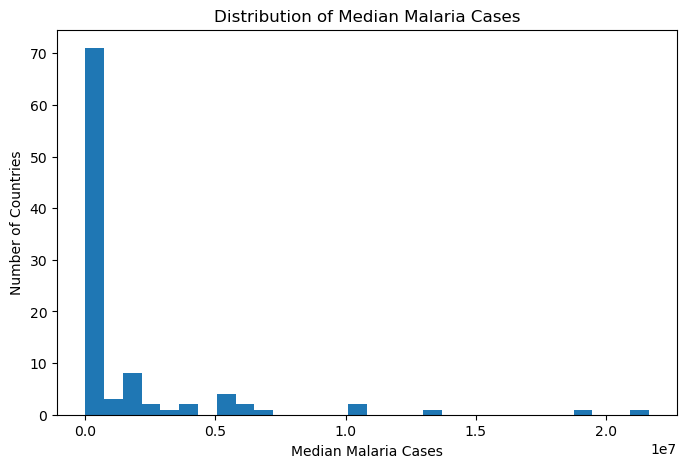

In [ ]:


plt.figure(figsize=(8,5))
plt.hist(df_final['Median_Malaria_Cases'], bins=30)
plt.xlabel('Median Malaria Cases')
plt.ylabel('Number of Countries')
plt.title('Distribution of Median Malaria Cases')
plt.show()

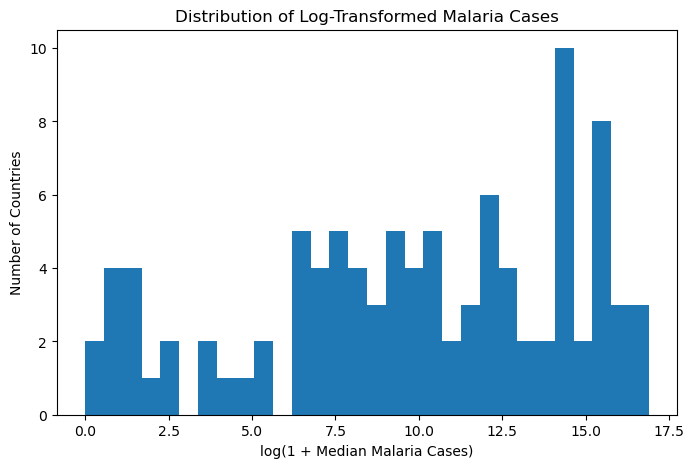

In [250]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(
    np.log1p(df_final['Median_Malaria_Cases']),
    bins=30
)
plt.xlabel('log(1 + Median Malaria Cases)')
plt.ylabel('Number of Countries')
plt.title('Distribution of Log-Transformed Malaria Cases')
plt.show()

In [251]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

X = df_final[predictor_cols]
y = np.log1p(df_final['Median_Malaria_Cases'])

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

rf = RandomForestRegressor(
    n_estimators=500,
    max_depth=3,
    min_samples_leaf=4,
    random_state=42
)

scores = cross_validate(
    rf,
    X,
    y,
    cv=kf,
    scoring={
        'r2': 'r2',
        'mae': 'neg_mean_absolute_error',
        'rmse': 'neg_root_mean_squared_error'
    }
)

print("R²:", scores['test_r2'].mean())
print("R² std:", scores['test_r2'].std())

print("MAE:", -scores['test_mae'].mean())
print("RMSE:", -scores['test_rmse'].mean())

R²: 0.5259388392739549
R² std: 0.14297276586042573
MAE: 2.535705479036749
RMSE: 3.0301266861949747


In [ ]:
#"Out of the six things you gave me, these are the ones I found most useful for making predictions."
# 
rf.fit(X, y)

importances = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(importances)

Median_Sanitation_Access_pct    0.735197
Median_GDP                      0.084775
Median_Rainfall                 0.065736
Median_Temp                     0.055578
Median_Urban_pct                0.037822
Median_Population_Density       0.020892
dtype: float64


Random Forest seems to perform better than oout MLR models. 
We will run fold test to see if we simply got lucky.

In [253]:
from sklearn.model_selection import cross_val_score

rf_scores = cross_val_score(
    rf,
    X,
    y,
    cv=kf,
    scoring='r2'
)

print("R² for each fold:")
print(rf_scores)

print("\nMean R²:", rf_scores.mean())
print("Standard deviation:", rf_scores.std())

R² for each fold:
[0.61369713 0.45624017 0.76229248 0.37208133 0.42538308]

Mean R²: 0.5259388392739549
Standard deviation: 0.14297276586042573


In [256]:
print(X.shape)
print(y.shape)

(99, 6)
(99,)
